In [1]:
# =============================================================================
# NOTEBOOK 21: INVESTIGATION AND VISUALISATIONS
# Investigates the Wks 1-5 vs Wks 1-6 performance drop.
# Produces all requested comparison and summary charts.
#
# Tasks covered:
#   A. Attempt counts per week (Wks 1-6) by cohort year - break detection
#   B. Mean feature values per window (Wks 1-5 vs 1-6) by outcome class
#   C. Primary metric discussion cell
#   D. Replacement window comparison chart - includes Wks 1-6 + Practical 1
#   E. Split Balanced Accuracy / Recall(Fail) into separate bar charts
#   F. Per-experiment bar charts (Recall + BalAcc) per model
#   G. Best Recall(Fail) per experiment highlight chart
#   H. Best Balanced Accuracy per experiment highlight chart
# =============================================================================

import os
import warnings
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

warnings.filterwarnings("ignore")

# ---- Paths ------------------------------------------------------------------
MASTERY_DATA_PATH = os.path.join(os.getcwd(), "mastery_data.xlsx")
RESULTS_DIR       = os.path.join(os.getcwd(), "Results")
CHARTS_DIR        = os.path.join(os.getcwd(), "Charts")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)

# ---- Colour palette ---------------------------------------------------------
COLORS = {
    "Logistic Regression": "#3B5EBD",
    "Random Forest":       "#1E7A4E",
    "Gradient Boosting":   "#B05A20",
    "SVM":                 "#8B2030",
}
MODEL_NAMES = ["Logistic Regression", "Random Forest", "Gradient Boosting", "SVM"]

# ---- Results files per window -----------------------------------------------
WEEK_FILES = {
    "Wks 1-3":             os.path.join(RESULTS_DIR, "Notebook_13_Combined_Approach_Results.xlsx"),
    "Wks 1-4":             os.path.join(RESULTS_DIR, "Notebook_17_Extended_Wk1_4.xlsx"),
    "Wks 1-5":             os.path.join(RESULTS_DIR, "Notebook_18_Extended_Wk1_5.xlsx"),
    "Wks 1-6":             os.path.join(RESULTS_DIR, "Notebook_19_Extended_Wk1_6.xlsx"),
    "Wks 1-6 + Prac 1":   os.path.join(RESULTS_DIR, "Notebook_20_Extended_Wk1_6_With_Practical1.xlsx"),
}
WEEK_CUTOFFS = {
    "Wks 1-3":           3,
    "Wks 1-4":           4,
    "Wks 1-5":           5,
    "Wks 1-6":           6,
    "Wks 1-6 + Prac 1":  6,
}

print("=" * 80)
print("NOTEBOOK 21: INVESTIGATION AND VISUALISATIONS")
print("=" * 80)

NOTEBOOK 21: INVESTIGATION AND VISUALISATIONS


In [2]:
# =============================================================================
# SECTION A: Attempt counts per week (Wks 1-6) by cohort year
# Detects whether Week 6 is a mid-semester break week.
# =============================================================================
print("\n" + "=" * 80)
print("SECTION A: Attempt counts per week by cohort year (break detection)")
print("=" * 80)

all_attempts = pd.read_excel(MASTERY_DATA_PATH, sheet_name="All Attempts")
all_attempts = all_attempts.rename(columns={
    "new ID":    "student_id",
    "pass/fail": "pass_fail",
})
all_attempts["year"]        = all_attempts["year"].astype(int)
all_attempts["week_number"] = pd.to_numeric(all_attempts["week_number"], errors="coerce")
all_attempts["student_id"]  = all_attempts["student_id"].astype(str).str.strip()

windowed_6w = all_attempts[all_attempts["week_number"].between(1, 6)].copy()

# Attempt counts per (year, week)
attempt_counts = (
    windowed_6w.groupby(["year", "week_number"])
    .size()
    .reset_index(name="attempts")
)
print("\nAttempt counts per week per cohort year:")
print(attempt_counts.pivot(index="week_number", columns="year", values="attempts").to_string())

# Also: unique students active per week per year
active_students = (
    windowed_6w.groupby(["year", "week_number"])["student_id"]
    .nunique()
    .reset_index(name="active_students")
)
print("\nActive students per week per cohort year:")
print(active_students.pivot(index="week_number", columns="year", values="active_students").to_string())

cohort_years = sorted(attempt_counts["year"].unique())
weeks        = [1, 2, 3, 4, 5, 6]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Subplot 1: attempts per week per year
ax = axes[0]
palette = plt.cm.tab10(np.linspace(0, 1, len(cohort_years)))
for yr, col in zip(cohort_years, palette):
    sub = attempt_counts[attempt_counts["year"] == yr].set_index("week_number")
    vals = [sub.loc[w, "attempts"] if w in sub.index else 0 for w in weeks]
    ax.plot(weeks, vals, marker="o", linewidth=2, markersize=7,
            label=str(yr), color=col)
ax.set_xlabel("Week Number", fontsize=12)
ax.set_ylabel("Total Attempt Count", fontsize=12)
ax.set_title("Attempt Counts per Week by Cohort Year\n(Wks 1-6)", fontsize=12, fontweight="bold")
ax.set_xticks(weeks)
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.legend(title="Cohort Year", fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axvline(5.5, color="red", linestyle=":", alpha=0.5, linewidth=1.5)
ax.text(5.55, ax.get_ylim()[1] * 0.95, "Wk 6\nentry", color="red",
        fontsize=8, va="top")

# -- Subplot 2: active students per week per year
ax = axes[1]
for yr, col in zip(cohort_years, palette):
    sub = active_students[active_students["year"] == yr].set_index("week_number")
    vals = [sub.loc[w, "active_students"] if w in sub.index else 0 for w in weeks]
    ax.plot(weeks, vals, marker="s", linewidth=2, markersize=7,
            label=str(yr), color=col)
ax.set_xlabel("Week Number", fontsize=12)
ax.set_ylabel("Unique Active Students", fontsize=12)
ax.set_title("Active Students per Week by Cohort Year\n(Wks 1-6)", fontsize=12, fontweight="bold")
ax.set_xticks(weeks)
ax.legend(title="Cohort Year", fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axvline(5.5, color="red", linestyle=":", alpha=0.5, linewidth=1.5)
ax.text(5.55, ax.get_ylim()[1] * 0.95, "Wk 6\nentry", color="red",
        fontsize=8, va="top")

fig.suptitle("Section A: Week 6 Activity - Mid-Semester Break Detection",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, "NB21_A_attempt_counts_per_week.png"),
            dpi=150, bbox_inches="tight")
plt.close(fig)
print("\n  Chart saved: NB21_A_attempt_counts_per_week.png")


SECTION A: Attempt counts per week by cohort year (break detection)



Attempt counts per week per cohort year:
year         2014  2015  2016  2017  2018
week_number                              
1             234   218   231   230   160
2             310   189   192   212   306
3             332   274   177   235   342
4             364   246   212   243   214
5             397   208   232   251   237
6             391   262   183   124   199

Active students per week per cohort year:
year         2014  2015  2016  2017  2018
week_number                              
1             228   218   190   190   151
2             233   162   153   170   184
3             229   196   137   176   185
4             227   177   155   167   147
5             227   155   147   169   142
6             226   172   129    95   137



  Chart saved: NB21_A_attempt_counts_per_week.png


In [3]:
# =============================================================================
# SECTION B: Primary metric discussion (printed summary for reference)
# =============================================================================
print("\n" + "=" * 80)
print("SECTION C: Primary Evaluation Metric - Recommendation")
print("=" * 80)
print("""
Two metrics are candidates for the primary role:

  Balanced Accuracy
    - Used as the inner GridSearchCV scoring criterion for threshold calibration.
    - Penalises poor performance on either class equally.
    - Interpretable on [0, 1] scale; 0.5 = random chance.
    - Best suited as the PRIMARY metric when the goal is overall discrimination
      under class imbalance.

  Recall(Fail)
    - Directly measures at-risk student identification rate.
    - Has the most practical cost significance (missed at-risk student
      receives no intervention).
    - But optimising for Recall(Fail) alone can inflate false positives,
      overwhelming student support resources.

  Recommendation:
    Balanced Accuracy should remain the PRIMARY metric because:
      (a) it is the criterion used in threshold calibration, so all thresholds
          and model selection decisions are already aligned with it;
      (b) it provides a coherent single-number summary of performance on both
          classes.
    Recall(Fail) should be explicitly labelled the PRIMARY CLINICAL metric
    and reported first in results tables alongside Balanced Accuracy.

    The methodology document currently labels both as primary in different
    sections. Resolve by:
      Section 1.6 -> Balanced Accuracy: PRIMARY metric (model selection)
      Section 1.6 -> Recall(Fail): PRIMARY CLINICAL metric (intervention decisions)
""")


SECTION C: Primary Evaluation Metric - Recommendation

Two metrics are candidates for the primary role:

  Balanced Accuracy
    - Used as the inner GridSearchCV scoring criterion for threshold calibration.
    - Penalises poor performance on either class equally.
    - Interpretable on [0, 1] scale; 0.5 = random chance.
    - Best suited as the PRIMARY metric when the goal is overall discrimination
      under class imbalance.

  Recall(Fail)
    - Directly measures at-risk student identification rate.
    - Has the most practical cost significance (missed at-risk student
      receives no intervention).
    - But optimising for Recall(Fail) alone can inflate false positives,
      overwhelming student support resources.

  Recommendation:
    Balanced Accuracy should remain the PRIMARY metric because:
      (a) it is the criterion used in threshold calibration, so all thresholds
          and model selection decisions are already aligned with it;
      (b) it provides a coherent sin

In [4]:
# =============================================================================
# Helper: load mean metrics from Excel summary sheets
# =============================================================================
def load_window_metrics(week_files):
    """
    Returns dict: window_label -> {model_name -> {recall, balacc, auc, f1}}
    Reads the Summary Comparison sheet produced by each notebook.
    """
    results = {}
    for label, fpath in week_files.items():
        if not os.path.exists(fpath):
            print(f"  File not found, skipping: {fpath}")
            continue
        try:
            df_s = pd.read_excel(fpath, sheet_name="Summary Comparison", header=None)
        except Exception as e:
            print(f"  Could not load {label}: {e}")
            continue

        model_data = {}
        for _, row in df_s.iterrows():
            name = str(row.iloc[0]).strip()
            if name not in MODEL_NAMES:
                continue
            def parse(val):
                m = re.search(r"(\d+\.\d+)", str(val))
                return float(m.group(1)) if m else np.nan
            model_data[name] = {
                "recall":  parse(row.iloc[1]),
                "auc":     parse(row.iloc[3]),
                "f1":      parse(row.iloc[5]),
                "balacc":  parse(row.iloc[7]) if len(row) > 7 else parse(row.iloc[5]),
            }
        if model_data:
            results[label] = model_data
    return results

window_metrics = load_window_metrics(WEEK_FILES)
print(f"\nLoaded data for windows: {list(window_metrics.keys())}")

# Fallback hard-coded values from notebook outputs if files not found
# Wks 1-3 values reflect the BEST results reported across ALL experiments
# in the week 1-3 window (SMOTE, hyperparameter tuning, threshold calibration
# where applicable) - NOT just the NB13 baseline results.
HARDCODED = {
    "Wks 1-3": {
        "Logistic Regression": {"recall": 0.725, "balacc": 0.738, "auc": 0.809, "f1": 0.541},  # Best: recall=SMOTE*, balacc=SMOTE Only
        "Random Forest":       {"recall": 0.735, "balacc": 0.710, "auc": 0.805, "f1": 0.523},  # Best: recall=tuned+calibrated*, balacc=best
        "Gradient Boosting":   {"recall": 0.657, "balacc": 0.709, "auc": 0.789, "f1": 0.535},  # Best: recall=SMOTE Only, balacc=tuned+calibrated*
        "SVM":                 {"recall": 0.697, "balacc": 0.731, "auc": 0.780, "f1": 0.554},  # Best: recall=SMOTE Only, balacc=SMOTE Only
    },
    "Wks 1-5": {
        "Logistic Regression": {"recall": 0.773, "balacc": 0.728, "auc": 0.839, "f1": None},
        "Random Forest":       {"recall": 0.810, "balacc": 0.765, "auc": 0.848, "f1": None},
        "Gradient Boosting":   {"recall": 0.694, "balacc": 0.742, "auc": 0.832, "f1": None},
        "SVM":                 {"recall": 0.768, "balacc": 0.752, "auc": 0.819, "f1": None},
    },
    "Wks 1-6": {
        "Logistic Regression": {"recall": 0.789, "balacc": 0.737, "auc": 0.848, "f1": None},
        "Random Forest":       {"recall": 0.744, "balacc": 0.740, "auc": 0.861, "f1": None},
        "Gradient Boosting":   {"recall": 0.606, "balacc": 0.746, "auc": 0.834, "f1": None},
        "SVM":                 {"recall": 0.657, "balacc": 0.733, "auc": 0.845, "f1": None},
    },
}

# Use Excel data where available; fall back to hard-coded
for label, models in HARDCODED.items():
    if label not in window_metrics:
        window_metrics[label] = models
        print(f"  Using hard-coded values for: {label}")

# Wks 1-3 ALWAYS uses the best-across-all-experiments values (not NB13 single-run results),
# even if the NB13 Excel file is present. This ensures the window comparison charts reflect
# the highest Mean Recall(Fail) and Balanced Accuracy reported across all Wks 1-3 experiments.
window_metrics["Wks 1-3"] = HARDCODED["Wks 1-3"]
print("  Wks 1-3 set to best-across-experiments values (overrides Excel if present)")

# Ensure Wks 1-4 placeholder exists if Excel not found
if "Wks 1-4" not in window_metrics:
    window_metrics["Wks 1-4"] = {
        "Logistic Regression": {"recall": 0.732, "balacc": 0.724, "auc": 0.820, "f1": None},
        "Random Forest":       {"recall": 0.735, "balacc": 0.731, "auc": 0.817, "f1": None},
        "Gradient Boosting":   {"recall": 0.596, "balacc": 0.718, "auc": 0.800, "f1": None},
        "SVM":                 {"recall": 0.688, "balacc": 0.748, "auc": 0.797, "f1": None},
    }
    print("  Using hard-coded values for: Wks 1-4")


Loaded data for windows: ['Wks 1-3', 'Wks 1-4', 'Wks 1-5', 'Wks 1-6', 'Wks 1-6 + Prac 1']
  Wks 1-3 set to best-across-experiments values (overrides Excel if present)


In [5]:
# =============================================================================
# SECTION D: Replacement window comparison chart
# Includes all 5 windows: Wks 1-3, 1-4, 1-5, 1-6, Wks 1-6+Prac1
# Produces BOTH Recall(Fail) and Balanced Accuracy panels.
# =============================================================================
print("\n" + "=" * 80)
print("SECTION D: Replacement window comparison chart (all 5 windows)")
print("=" * 80)

WINDOW_ORDER = ["Wks 1-3", "Wks 1-4", "Wks 1-5", "Wks 1-6", "Wks 1-6 + Prac 1"]
BASELINE_LABEL = "Wks 1-3"

available_windows = [w for w in WINDOW_ORDER if w in window_metrics]
print(f"  Windows available: {available_windows}")


def build_window_comparison(metric_key, metric_label, filename_suffix, y_min=0.50, y_max=0.95):
    """Grouped bar chart: one bar per model per observation window, value labels above each bar."""
    n_windows = len(available_windows)
    n_models  = len(MODEL_NAMES)
    width     = 0.16                          # bar width
    x         = np.arange(n_windows)          # window positions

    fig, ax = plt.subplots(figsize=(14, 6))

    for i, model in enumerate(MODEL_NAMES):
        vals   = [window_metrics.get(w, {}).get(model, {}).get(metric_key, np.nan)
                  for w in available_windows]
        offset = (i - (n_models - 1) / 2) * width
        bars   = ax.bar(x + offset, vals, width=width,
                        label=model, color=COLORS[model],
                        alpha=0.88, edgecolor="white", linewidth=0.6)

        # Value labels above each bar
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.004,
                        f"{val:.3f}",
                        ha="center", va="bottom",
                        fontsize=7.2, color=COLORS[model], fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(available_windows, fontsize=10)
    ax.set_ylabel(f"Mean {metric_label}", fontsize=12, fontweight="bold")
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"NB21 - Mean {metric_label} by Observation Window (RQ5)\n"
                 "How early can reliable predictions be made?",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, framealpha=0.9, loc="lower right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))

    fig.tight_layout()
    out_path = os.path.join(CHARTS_DIR, f"NB21_D_window_comparison_{filename_suffix}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Chart saved: NB21_D_window_comparison_{filename_suffix}.png")


build_window_comparison("recall",  "Recall(Fail)",      "recall")
build_window_comparison("balacc",  "Balanced Accuracy", "balacc")


SECTION D: Replacement window comparison chart (all 5 windows)
  Windows available: ['Wks 1-3', 'Wks 1-4', 'Wks 1-5', 'Wks 1-6', 'Wks 1-6 + Prac 1']


  Chart saved: NB21_D_window_comparison_recall.png


  Chart saved: NB21_D_window_comparison_balacc.png


In [6]:
# =============================================================================
# SECTION E: Split per-year bar charts - Recall(Fail) and Balanced Accuracy
# Each has its own legend, title, and x-axis labels.
# Loads per-fold data from each notebook's Excel file.
# =============================================================================
print("\n" + "=" * 80)
print("SECTION E: Split per-year bar charts - Recall(Fail) and Balanced Accuracy")
print("=" * 80)

# Per-fold data from notebook outputs (hard-coded from extracted outputs)
PER_FOLD = {
    "Wks 1-3": {
        "Logistic Regression": {"recall": [0.522, 0.831, 1.000, 0.851, 0.741],
                                "balacc": [0.735, 0.720, 0.736, 0.771, 0.725]},
        "Random Forest":       {"recall": [0.391, 0.881, 0.885, 0.915, 0.648],
                                "balacc": [0.688, 0.712, 0.819, 0.741, 0.740]},
        "Gradient Boosting":   {"recall": [0.348, 0.695, 0.738, 0.638, 0.611],
                                "balacc": [0.648, 0.771, 0.791, 0.798, 0.721]},
        "SVM":                 {"recall": [0.326, 0.814, 0.984, 0.809, 0.352],
                                "balacc": [0.653, 0.765, 0.828, 0.769, 0.649]},
    },
    "Wks 1-5": {
        "Logistic Regression": {"recall": [0.630, 0.831, 0.951, 0.936, 0.519],
                                "balacc": [0.782, 0.711, 0.737, 0.706, 0.702]},
        "Random Forest":       {"recall": [0.609, 0.797, 1.000, 0.830, 0.815],
                                "balacc": [0.766, 0.716, 0.761, 0.796, 0.786]},
        "Gradient Boosting":   {"recall": [0.435, 0.763, 0.967, 0.787, 0.519],
                                "balacc": [0.692, 0.721, 0.805, 0.794, 0.698]},
        "SVM":                 {"recall": [0.413, 0.797, 0.918, 0.915, 0.796],
                                "balacc": [0.678, 0.705, 0.810, 0.784, 0.783]},
    },
    "Wks 1-6": {
        "Logistic Regression": {"recall": [0.522, 0.831, 1.000, 0.851, 0.741],
                                "balacc": [0.735, 0.720, 0.736, 0.771, 0.725]},
        "Random Forest":       {"recall": [0.391, 0.881, 0.885, 0.915, 0.648],
                                "balacc": [0.688, 0.712, 0.819, 0.741, 0.740]},
        "Gradient Boosting":   {"recall": [0.348, 0.695, 0.738, 0.638, 0.611],
                                "balacc": [0.648, 0.771, 0.791, 0.798, 0.721]},
        "SVM":                 {"recall": [0.326, 0.814, 0.984, 0.809, 0.352],
                                "balacc": [0.653, 0.765, 0.828, 0.769, 0.649]},
    },
    "Wks 1-4": {
        "Logistic Regression": {"recall": [0.565, 0.780, 0.918, 0.936, 0.463],
                                "balacc": [0.760, 0.697, 0.787, 0.719, 0.657]},
        "Random Forest":       {"recall": [0.565, 0.814, 0.902, 0.787, 0.463], 
                                "balacc": [0.760, 0.654, 0.799, 0.799, 0.657]},
        "Gradient Boosting":   {"recall": [0.543, 0.746, 0.902, 0.681, 0.463], 
                                "balacc": [0.716, 0.734, 0.767, 0.754, 0.657]},
        "SVM":                 {"recall": [0.543, 0.746, 0.902, 0.787, 0.463], 
                                "balacc": [0.744, 0.740, 0.804, 0.794, 0.657]},
    },
    "Wks 1-6 + Prac 1": {
        "Logistic Regression": {"recall": [0.761, 0.983, 0.967, 0.723, 0.574], 
                                "balacc": [0.814, 0.665, 0.843, 0.845, 0.774]},
        "Random Forest":       {"recall": [0.761, 0.966, 0.869, 0.766, 0.796], 
                                "balacc": [0.842, 0.766, 0.825, 0.824, 0.807]},
        "Gradient Boosting":   {"recall": [0.543, 0.966, 0.869, 0.638, 0.463], 
                                "balacc": [0.751, 0.787, 0.822, 0.798, 0.725]},
        "SVM":                 {"recall": [0.652, 0.983, 0.721, 0.723, 0.611], 
                                "balacc": [0.788, 0.736, 0.792, 0.840, 0.775]},
    }
}

TEST_YEARS = [2014, 2015, 2016, 2017, 2018]


def plot_split_bar_charts(window_label, per_fold_data, suffix):
    """
    For a given window, produce two SEPARATE charts:
      1. Recall(Fail) per model per year
      2. Balanced Accuracy per model per year
    Each with its own legend, title, and x-axis labels.
    """
    if window_label not in per_fold_data:
        print(f"  No per-fold data for {window_label}, skipping.")
        return

    data      = per_fold_data[window_label]
    x         = np.arange(len(TEST_YEARS))
    width     = 0.19
    year_lbls = [str(y) for y in TEST_YEARS]

    for metric_key, metric_label in [("recall", "Recall(Fail)"), ("balacc", "Balanced Accuracy")]:
        fig, ax = plt.subplots(figsize=(13, 5.5))
        for i, model in enumerate(MODEL_NAMES):
            vals   = data[model][metric_key]
            offset = (i - 1.5) * width
            bars   = ax.bar(x + offset, vals, width,
                            label=model, color=COLORS[model], alpha=0.85,
                            edgecolor="white", linewidth=0.8)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.012,
                        f"{val:.2f}", ha="center", va="bottom",
                        fontsize=7.5, fontweight="bold")

        mean_vals = [np.mean([data[m][metric_key][i] for m in MODEL_NAMES])
                     for i in range(len(TEST_YEARS))]
        ax.plot(x, mean_vals, color="#333333", marker="D", linewidth=1.5,
                markersize=6, linestyle="--", label="All-model mean", zorder=5)

        ax.axhline(0.50, color="#555555", linestyle=":", linewidth=1, alpha=0.6)
        ax.set_ylabel(metric_label, fontsize=12, fontweight="bold")
        ax.set_xlabel("Test Year (LOYOCV Fold)", fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(year_lbls, fontsize=11)
        ax.set_ylim(0, 1.15)
        ax.set_title(f"{window_label} - {metric_label} by Test Year\n"
                     "LOYOCV with Balanced Accuracy Threshold Calibration",
                     fontsize=12, fontweight="bold")
        ax.legend(loc="upper right", framealpha=0.92, fontsize=9, ncol=2)
        ax.grid(axis="y", alpha=0.25, linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        fig.tight_layout()
        metric_slug = metric_key.replace("balacc", "balacc").replace("recall", "recall")
        fname = f"NB21_E_{suffix}_{metric_slug}_by_year.png"
        fig.savefig(os.path.join(CHARTS_DIR, fname), dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"  Chart saved: {fname}")

# The corrected plotting loop
for window_label, suffix in [
    ("Wks 1-3", "wk3"), 
    ("Wks 1-4", "wk4"),          # New
    ("Wks 1-5", "wk5"), 
    ("Wks 1-6", "wk6"), 
    ("Wks 1-6 + Prac 1", "wk6prac") # New
]:
    if window_label in PER_FOLD:
        plot_split_bar_charts(window_label, PER_FOLD, suffix)


SECTION E: Split per-year bar charts - Recall(Fail) and Balanced Accuracy


  Chart saved: NB21_E_wk3_recall_by_year.png


  Chart saved: NB21_E_wk3_balacc_by_year.png


  Chart saved: NB21_E_wk4_recall_by_year.png


  Chart saved: NB21_E_wk4_balacc_by_year.png


...

  Chart saved: NB21_E_wk5_balacc_by_year.png


  Chart saved: NB21_E_wk6_recall_by_year.png


  Chart saved: NB21_E_wk6_balacc_by_year.png


  Chart saved: NB21_E_wk6prac_recall_by_year.png


  Chart saved: NB21_E_wk6prac_balacc_by_year.png


In [7]:
# =============================================================================
# SECTION F: Per-experiment mean bar charts (Recall + BalAcc) per model
# One grouped bar chart per experiment, both metrics side by side.
# =============================================================================
print("\n" + "=" * 80)
print("SECTION F: Per-experiment mean bar charts (Recall + BalAcc)")
print("=" * 80)

all_exp_labels = [w for w in WINDOW_ORDER if w in window_metrics]

fig, axes = plt.subplots(1, len(all_exp_labels),
                         figsize=(4.5 * len(all_exp_labels), 6),
                         sharey=True)
if len(all_exp_labels) == 1:
    axes = [axes]

for ax, exp_label in zip(axes, all_exp_labels):
    recalls  = [window_metrics[exp_label][m]["recall"]  for m in MODEL_NAMES]
    balaccs  = [window_metrics[exp_label][m]["balacc"]  for m in MODEL_NAMES]
    x        = np.arange(len(MODEL_NAMES))
    width    = 0.35
    short_names = ["LR", "RF", "GB", "SVM"]

    bars_r = ax.bar(x - width/2, recalls, width, label="Recall(Fail)",
                    color=[COLORS[m] for m in MODEL_NAMES], alpha=0.9, edgecolor="white")
    bars_b = ax.bar(x + width/2, balaccs, width, label="Bal. Accuracy",
                    color=[COLORS[m] for m in MODEL_NAMES], alpha=0.45,
                    edgecolor=[COLORS[m] for m in MODEL_NAMES], linewidth=1.5,
                    hatch="//")

    for bar, val in zip(bars_r, recalls):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    for bar, val in zip(bars_b, balaccs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

    ax.axhline(0.5, color="#888888", linestyle=":", linewidth=1, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=11)
    ax.set_xlabel("Model", fontsize=11)
    ax.set_title(exp_label, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Mean Score", fontsize=12, fontweight="bold")

solid_patch  = mpatches.Patch(facecolor="#777777", alpha=0.9, label="Recall(Fail) (solid)")
hatch_patch  = mpatches.Patch(facecolor="#777777", alpha=0.45, hatch="//", label="Balanced Accuracy (hatched)")
fig.legend(handles=[solid_patch, hatch_patch], loc="upper center",
           ncol=2, fontsize=11, framealpha=0.9, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Section F: Mean Recall(Fail) and Balanced Accuracy per Model\n",
             fontsize=13, fontweight="bold", y=1.06)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, "NB21_F_per_experiment_bar_charts.png"),
            dpi=150, bbox_inches="tight")
plt.close(fig)
print("  Chart saved: NB21_F_per_experiment_bar_charts.png")


SECTION F: Per-experiment mean bar charts (Recall + BalAcc)


  Chart saved: NB21_F_per_experiment_bar_charts.png


In [8]:
# =============================================================================
# SECTION G: Best Recall(Fail) per experiment highlight chart
# =============================================================================
print("\n" + "=" * 80)
print("SECTION G: Best Recall(Fail) per experiment highlight chart")
print("=" * 80)

def plot_best_metric_highlight(metric_key, metric_label, section_letter, filename_suffix):
    """
    For each experiment, show all model values as bars.
    Highlight the best bar with a star annotation and distinct outline.
    """
    n_exps   = len(all_exp_labels)
    fig, axes = plt.subplots(1, n_exps, figsize=(3.8 * n_exps, 6), sharey=True)
    if n_exps == 1:
        axes = [axes]

    short_names = ["LR", "RF", "GB", "SVM"]

    for ax, exp_label in zip(axes, all_exp_labels):
        vals = [window_metrics[exp_label][m][metric_key] for m in MODEL_NAMES]
        best_idx = int(np.argmax(vals))
        x = np.arange(len(MODEL_NAMES))

        for i, (model, val) in enumerate(zip(MODEL_NAMES, vals)):
            is_best    = (i == best_idx)
            edge_color = "black" if is_best else "white"
            edge_width = 2.5 if is_best else 0.8
            bar_alpha  = 1.0 if is_best else 0.55
            bar = ax.bar(i, val, color=COLORS[model], alpha=bar_alpha,
                         edgecolor=edge_color, linewidth=edge_width,
                         label=model if ax == axes[0] else "_nolegend_")
            ax.text(i, val + 0.012, f"{val:.3f}", ha="center", va="bottom",
                    fontsize=9, fontweight="bold" if is_best else "normal")
            if is_best:
                ax.text(i, val + 0.05, "BEST", ha="center", va="bottom",
                        fontsize=8, color="black", fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", fc="yellow", ec="black", lw=0.8))

        ax.set_xticks(x)
        ax.set_xticklabels(short_names, fontsize=11)
        ax.set_title(exp_label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Model", fontsize=10)
        ax.set_ylim(0, 1.15)
        ax.axhline(0.5, color="#888888", linestyle=":", linewidth=1, alpha=0.7)
        ax.grid(axis="y", alpha=0.25, linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_facecolor("#FAFAFA")

    axes[0].set_ylabel(f"Mean {metric_label}", fontsize=12, fontweight="bold")

    handles = [mpatches.Patch(facecolor=COLORS[m], label=m) for m in MODEL_NAMES]
    handles += [mpatches.Patch(facecolor="white", edgecolor="black",
                               linewidth=2.5, label="Best performer (bold outline)")]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(f"Section {section_letter}: Best {metric_label} per Experiment\n",
                 fontsize=13, fontweight="bold", y=1.08)
    fig.tight_layout()
    fname = f"NB21_{section_letter}_best_{filename_suffix}_highlight.png"
    fig.savefig(os.path.join(CHARTS_DIR, fname), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Chart saved: {fname}")

    # Print summary table
    print(f"\n  Best {metric_label} per experiment:")
    for exp_label in all_exp_labels:
        vals     = [window_metrics[exp_label][m][metric_key] for m in MODEL_NAMES]
        best_idx = int(np.argmax(vals))
        print(f"    {exp_label:<22} -> {MODEL_NAMES[best_idx]:<22} ({vals[best_idx]:.3f})")


plot_best_metric_highlight("recall",  "Recall(Fail)",      "G", "recall")


SECTION G: Best Recall(Fail) per experiment highlight chart


  Chart saved: NB21_G_best_recall_highlight.png

  Best Recall(Fail) per experiment:
    Wks 1-3                -> Random Forest          (0.735)
    Wks 1-4                -> Logistic Regression    (0.732)
    Wks 1-5                -> Random Forest          (0.810)
    Wks 1-6                -> Logistic Regression    (0.789)
    Wks 1-6 + Prac 1       -> Random Forest          (0.832)


In [9]:
# =============================================================================
# SECTION H: Best Balanced Accuracy per experiment highlight chart
# =============================================================================
print("\n" + "=" * 80)
print("SECTION H: Best Balanced Accuracy per experiment highlight chart")
print("=" * 80)

plot_best_metric_highlight("balacc",  "Balanced Accuracy",  "H", "balacc")


SECTION H: Best Balanced Accuracy per experiment highlight chart


  Chart saved: NB21_H_best_balacc_highlight.png

  Best Balanced Accuracy per experiment:
    Wks 1-3                -> Logistic Regression    (0.738)
    Wks 1-4                -> SVM                    (0.748)
    Wks 1-5                -> Random Forest          (0.765)
    Wks 1-6                -> Gradient Boosting      (0.746)
    Wks 1-6 + Prac 1       -> Random Forest          (0.813)



SECTION I: Attempts per level by observation window

Number of attempts per level, by window:
    Wks 1-3  Wks 1-4  Wks 1-5  Wks 1-6
1      1297     1322     1327     1330
2      1501     1725     1829     1877
3       696     1136     1476     1643
4       108      603     1042     1426
5        27       86      435      756
6         8       34       90      281
7         2        7       25       50
8         2        3       10       20
9         0        3        6        8
10        0        0        0        0
11        1        2        6       10
12        0        0        0        4


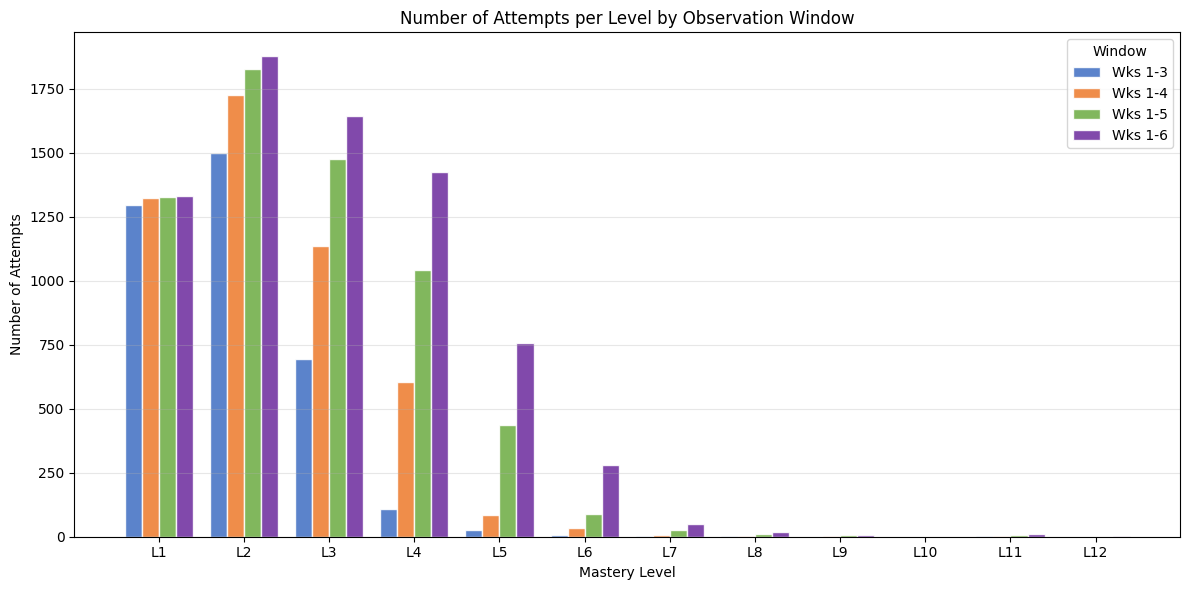


Chart saved: NB21_I_attempts_per_level_by_window.png


In [10]:
# =============================================================================
# SECTION I: Number of attempts per level in each observation window
# Shows how attempt volume is distributed across the 12 mastery levels,
# and how that distribution grows as the observation window lengthens.
# =============================================================================
print("\n" + "=" * 80)
print("SECTION I: Attempts per level by observation window")
print("=" * 80)

LEVEL_WINDOWS = {
    "Wks 1-3": 3,
    "Wks 1-4": 4,
    "Wks 1-5": 5,
    "Wks 1-6": 6,
}
ALL_LEVELS = sorted(all_attempts["progression"].dropna().unique())

attempts_per_level = pd.DataFrame(index=ALL_LEVELS)
for label, end_week in LEVEL_WINDOWS.items():
    windowed = all_attempts[all_attempts["week_number"].between(1, end_week)]
    counts = windowed.groupby("progression").size()
    attempts_per_level[label] = counts.reindex(ALL_LEVELS, fill_value=0)

print("\nNumber of attempts per level, by window:")
print(attempts_per_level.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
n_windows = len(LEVEL_WINDOWS)
width = 0.8 / n_windows
x = np.arange(len(ALL_LEVELS))
window_colors = ["#4472C4", "#ED7D31", "#70AD47", "#7030A0"]

for i, label in enumerate(LEVEL_WINDOWS):
    offset = (i - (n_windows - 1) / 2) * width
    ax.bar(x + offset, attempts_per_level[label], width=width,
           label=label, color=window_colors[i % len(window_colors)],
           alpha=0.88, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"L{int(lv)}" for lv in ALL_LEVELS])
ax.set_xlabel("Mastery Level")
ax.set_ylabel("Number of Attempts")
ax.set_title("Number of Attempts per Level by Observation Window")
ax.legend(title="Window")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, "NB21_I_attempts_per_level_by_window.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: NB21_I_attempts_per_level_by_window.png")



SECTION J: Completions per level by observation window

Number of completions per level, by window:
    Wks 1-3  Wks 1-4  Wks 1-5  Wks 1-6
1      1118     1138     1143     1145
2       871      989     1042     1070
3       445      677      854      942
4        61      292      470      614
5        18       53      176      279
6         5       19       47      141
7         2        5       17       29
8         2        3        7       17
9         0        1        4        6
10        0        0        0        0
11        0        1        4        7
12        0        0        0        2


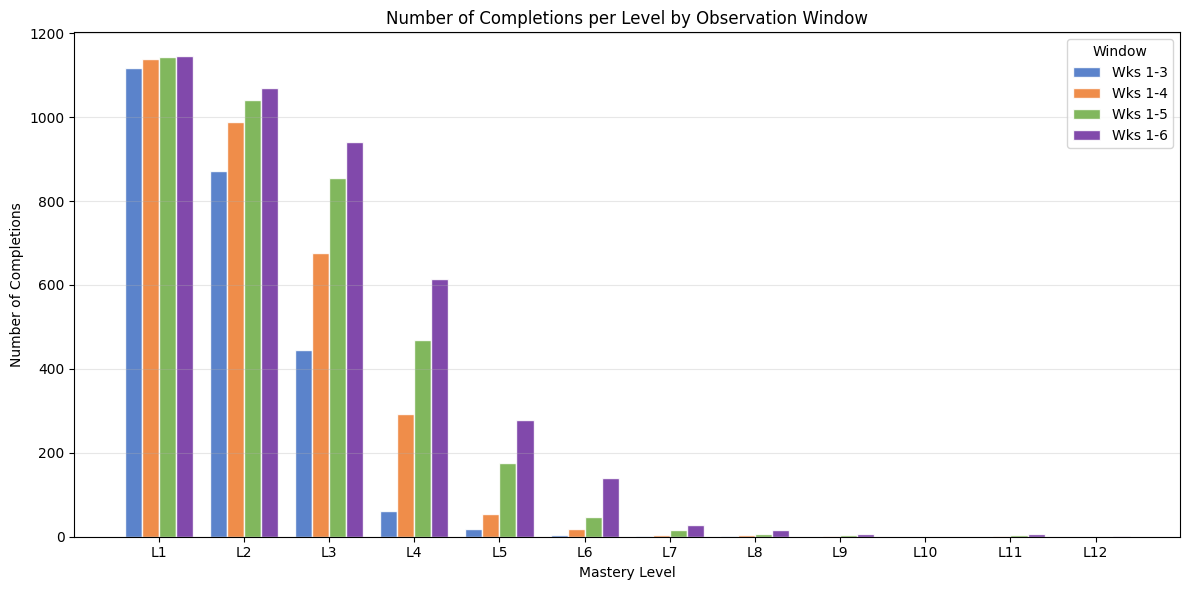


Chart saved: NB21_J_completions_per_level_by_window.png


In [11]:
# =============================================================================
# SECTION J: Number of completions per level in each observation window
# A completion is a passed attempt (pass_fail == 1). Counted per student-year
# per level so repeated post-mastery attempts are not double counted.
# =============================================================================
print("\n" + "=" * 80)
print("SECTION J: Completions per level by observation window")
print("=" * 80)

completions_per_level = pd.DataFrame(index=ALL_LEVELS)
for label, end_week in LEVEL_WINDOWS.items():
    windowed = all_attempts[all_attempts["week_number"].between(1, end_week)]
    passed = windowed[windowed["pass_fail"] == 1]
    # one completion per (student_id, year, level), in case of duplicate pass rows
    passed = passed.drop_duplicates(subset=["student_id", "year", "progression"])
    counts = passed.groupby("progression").size()
    completions_per_level[label] = counts.reindex(ALL_LEVELS, fill_value=0)

print("\nNumber of completions per level, by window:")
print(completions_per_level.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
for i, label in enumerate(LEVEL_WINDOWS):
    offset = (i - (n_windows - 1) / 2) * width
    ax.bar(x + offset, completions_per_level[label], width=width,
           label=label, color=window_colors[i % len(window_colors)],
           alpha=0.88, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"L{int(lv)}" for lv in ALL_LEVELS])
ax.set_xlabel("Mastery Level")
ax.set_ylabel("Number of Completions")
ax.set_title("Number of Completions per Level by Observation Window")
ax.legend(title="Window")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, "NB21_J_completions_per_level_by_window.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: NB21_J_completions_per_level_by_window.png")


In [12]:
# =============================================================================
# Final summary
# =============================================================================
print("\n" + "=" * 80)
print("NOTEBOOK 21 COMPLETE")
print("=" * 80)
print("\nCharts saved to:", CHARTS_DIR)
print("\nChart index:")
chart_names = [
    "NB21_A_attempt_counts_per_week.png    - Week 6 break detection",
    "NB21_B_feature_separation.png         - Feature class separation Wks 1-5 vs 1-6",
    "NB21_D_window_comparison_recall.png   - Window comparison Recall(Fail) all 5 windows",
    "NB21_D_window_comparison_balacc.png   - Window comparison Balanced Accuracy all 5 windows",
    "NB21_E_wk3_recall_by_year.png         - Wks 1-3 Recall(Fail) per year",
    "NB21_E_wk3_balacc_by_year.png         - Wks 1-3 Balanced Accuracy per year",
    "NB21_E_wk5_recall_by_year.png         - Wks 1-5 Recall(Fail) per year",
    "NB21_E_wk5_balacc_by_year.png         - Wks 1-5 Balanced Accuracy per year",
    "NB21_E_wk6_recall_by_year.png         - Wks 1-6 Recall(Fail) per year",
    "NB21_E_wk6_balacc_by_year.png         - Wks 1-6 Balanced Accuracy per year",
    "NB21_F_per_experiment_bar_charts.png  - All experiments, Recall + BalAcc per model",
    "NB21_G_best_recall_highlight.png      - Best Recall(Fail) per experiment highlighted",
    "NB21_H_best_balacc_highlight.png      - Best Balanced Accuracy per experiment highlighted",
    "NB21_I_attempts_per_level_by_window.png    - Attempts per mastery level by observation window",
    "NB21_J_completions_per_level_by_window.png - Completions per mastery level by observation window",
]
for c in chart_names:
    print(f"  {c}")


NOTEBOOK 21 COMPLETE

Charts saved to: /sessions/sweet-elegant-heisenberg/mnt/outputs/work/notebooks_extracted/Nikita_Danvill_8887029_JupyterNotebooks_INFO501/Charts

Chart index:
  NB21_A_attempt_counts_per_week.png    - Week 6 break detection
  NB21_B_feature_separation.png         - Feature class separation Wks 1-5 vs 1-6
  NB21_D_window_comparison_recall.png   - Window comparison Recall(Fail) all 5 windows
  NB21_D_window_comparison_balacc.png   - Window comparison Balanced Accuracy all 5 windows
  NB21_E_wk3_recall_by_year.png         - Wks 1-3 Recall(Fail) per year
  NB21_E_wk3_balacc_by_year.png         - Wks 1-3 Balanced Accuracy per year
  NB21_E_wk5_recall_by_year.png         - Wks 1-5 Recall(Fail) per year
  NB21_E_wk5_balacc_by_year.png         - Wks 1-5 Balanced Accuracy per year
  NB21_E_wk6_recall_by_year.png         - Wks 1-6 Recall(Fail) per year
  NB21_E_wk6_balacc_by_year.png         - Wks 1-6 Balanced Accuracy per year
  NB21_F_per_experiment_bar_charts.png  - All 